In [44]:
import pandas as pd
import sqlite3

In [45]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [46]:
query = """
SELECT datetime
FROM pageviews
WHERE uid NOT LIKE 'admin_%'
"""

pageviews_user = pd.io.sql.read_sql(query, conn)

In [47]:
pageviews_user['datetime'] = pd.to_datetime(pageviews_user['datetime'])
pageviews_user['date'] = pageviews_user['datetime'].dt.date
views_per_day = pageviews_user.groupby('date').size().reset_index(name='views')

In [48]:
views_per_day.shape

(33, 2)

<Axes: title={'center': 'Views per day'}, xlabel='date'>

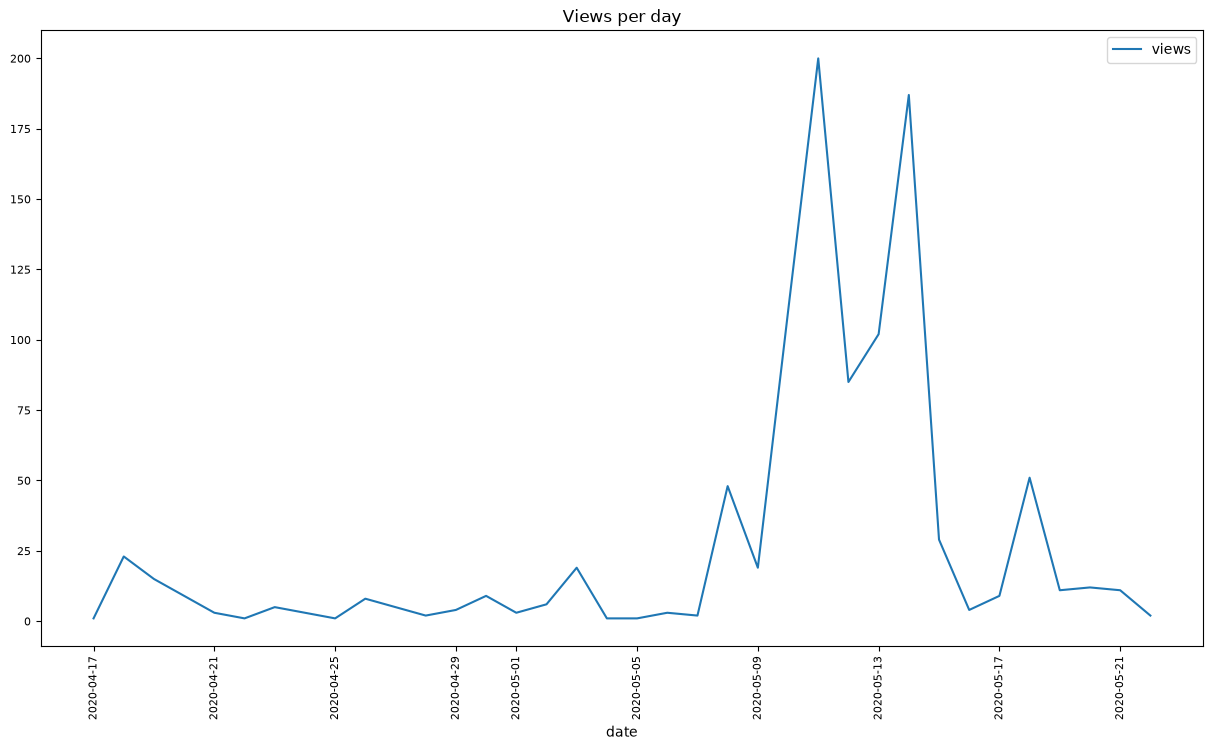

In [49]:
views_per_day.plot(
    x='date',
    y='views',
    figsize=(15, 8),
    title='Views per day',
    legend = True,
    label='views',
    rot=90,
    fontsize=8,
)

In [50]:
conn.close()